In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src import load_and_prep_data, run_validation_loop, HawkesExp

In [9]:
# data
sequences = load_and_prep_data('data/raw/retail_data.csv')

# stats
factory_reg = lambda p: HawkesExp(baseline_model=p, penalty_weight=50.0)
df = run_validation_loop(sequences, model_factory=factory_reg, label="Regularized", min_events=20)

Running 'Regularized': N=107 users
Fitting Global Profile...


100%|██████████| 107/107 [00:00<00:00, 147.36it/s]


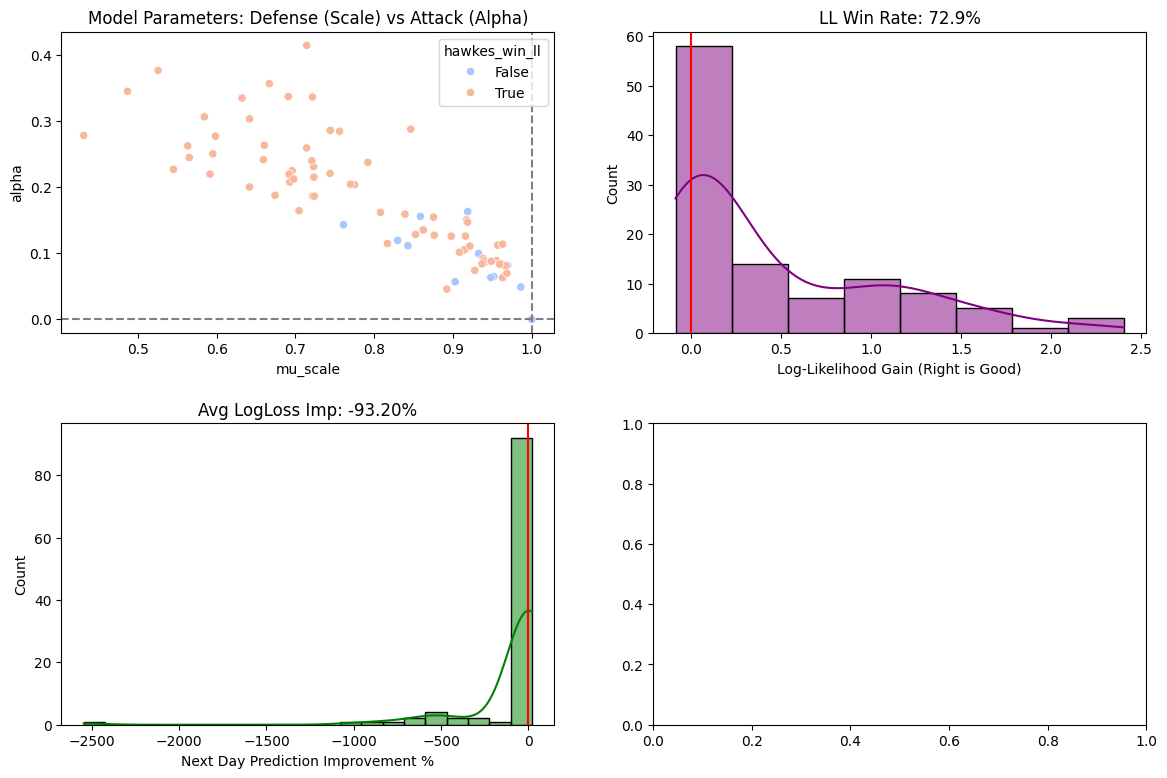

In [10]:
import seaborn as sns
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
plt.subplots_adjust(hspace=0.3)

# Alpha & Mu Scale
sns.scatterplot(data=df, x='mu_scale', y='alpha', hue='hawkes_win_ll', ax=ax[0,0], palette='coolwarm')
ax[0,0].set_title('Model Parameters: Defense (Scale) vs Attack (Alpha)')
ax[0,0].axvline(1, c='gray', ls='--'); ax[0,0].axhline(0, c='gray', ls='--')

# LL Improvement
sns.histplot(df['imp_ll'], ax=ax[0,1], kde=True, color='purple')
ax[0,1].set_title(f"LL Win Rate: {(df['hawkes_win_ll'].mean()):.1%}")
ax[0,1].set_xlabel('Log-Likelihood Gain (Right is Good)')
ax[0,1].axvline(0, c='red')

# LogLoss Improvement (тупая метрика)
sns.histplot(df['imp_logloss'], ax=ax[1,0], kde=True, color='green')
ax[1,0].set_title(f"Avg LogLoss Imp: {df['imp_logloss'].mean():.2f}%")
ax[1,0].set_xlabel('Next Day Prediction Improvement %')
ax[1,0].axvline(0, c='red')

plt.show()